In [15]:
import SUITPy.flatmap as flatmap
import matplotlib.pyplot as plt
import nibabel as nb
import smarts_cerebellum.globals as gl
import nitools as nt
import os
from smarts_cerebellum.util import smooth_gifti

In [16]:
space = 'MNISym'
segment = 'GM_mod'
group = 'patients'
img_stat = 'median'

stats = 'nanmean'

fname = f'{group}_{space}C_{segment}_slope_{img_stat}.nii'
file = os.path.join(gl.baseDir, 'regression', f'{img_stat}s', fname)
funcdata = flatmap.vol_to_surf(file, space = space, stats = stats)
# flatmap.plot(data=funcdata, cmap='bwr', new_figure=True, colorbar=True, cscale=(-.0025, .0025), threshold=[-.0001, .0001])
# plt.title(f'{group} {segment} {img_stat} slope')
# plt.show()

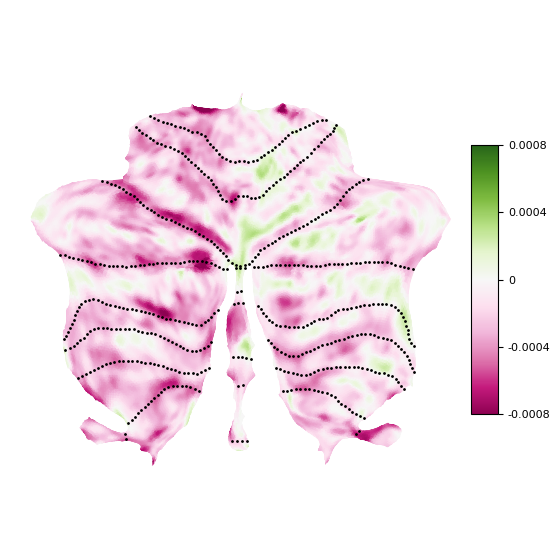

In [19]:
gifti = nt.make_func_gifti(funcdata, anatomical_struct='cerebellum', column_names=['GM_mod'])
gifti_smooth = smooth_gifti(gifti, fwhm=2)
funcdata_smooth = nt.get_gifti_data_matrix(gifti_smooth)

flatmap.plot(data=funcdata_smooth, cmap='PiYG', new_figure=True, colorbar=True, cscale=(-.0008, .0008)) # threshold=[-.00025, .00025])
#plt.title(f'{group} {segment} {img_stat} slope')

fig = plt.gcf() # get the plotted gifti
fig.savefig('figure/surface_projection.pdf')

plt.show()